In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             mean_absolute_error, r2_score)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.model_selection import cross_val_predict

In [43]:
df = pd.read_csv("mp_sponsorwise_ml_features.csv")
df.shape

(70000, 69)

In [44]:
df.head()

,month,day_of_week,is_weekend,is_festive,is_indoor,temperature,is_raining,humidity,venue_capacity,ticket_price,...,brand_category_Real Estate,brand_category_Telecom,brand_kpi_hybrid,brand_kpi_leads,brand_kpi_sales,brand_city_focus_metro,brand_city_focus_pilgrimage,brand_city_focus_tier2,actual_attendance,feasible_to_sponsor
0,3,0,0,1,0,28.31,0,25.91,6865,200,...,1,0,1,0,0,1,0,0,6865,0
1,3,0,0,1,0,28.31,0,25.91,6865,200,...,0,0,1,0,0,1,0,0,6865,0
2,3,0,0,1,0,28.31,0,25.91,6865,200,...,0,0,0,0,0,0,0,0,6865,0
3,3,0,0,1,0,28.31,0,25.91,6865,200,...,0,0,0,1,0,0,0,0,6865,1
4,3,0,0,1,0,28.31,0,25.91,6865,200,...,0,0,1,0,0,0,0,1,6865,0


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 69 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   month                                70000 non-null  int64  
 1   day_of_week                          70000 non-null  int64  
 2   is_weekend                           70000 non-null  int64  
 3   is_festive                           70000 non-null  int64  
 4   is_indoor                            70000 non-null  int64  
 5   temperature                          70000 non-null  float64
 6   is_raining                           70000 non-null  int64  
 7   humidity                             70000 non-null  float64
 8   venue_capacity                       70000 non-null  int64  
 9   ticket_price                         70000 non-null  int64  
 10  marketing_budget                     70000 non-null  int64  
 11  organizer_reputation        

In [46]:
df.describe()

,month,day_of_week,is_weekend,is_festive,is_indoor,temperature,is_raining,humidity,venue_capacity,ticket_price,...,brand_category_Real Estate,brand_category_Telecom,brand_kpi_hybrid,brand_kpi_leads,brand_kpi_sales,brand_city_focus_metro,brand_city_focus_pilgrimage,brand_city_focus_tier2,actual_attendance,feasible_to_sponsor
count,70000.000000,70000.000000,70000.00000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,6.490000,2.966900,0.27600,0.328600,0.455000,26.203065,0.255800,54.265564,22135.199500,610.447000,...,0.092386,0.091929,0.369543,0.282771,0.056614,0.282757,0.079257,0.147329,14864.679900,0.347343
std,3.460588,1.992049,0.44702,0.469708,0.497974,6.257335,0.436313,20.492560,17596.578786,1245.155113,...,0.289572,0.288927,0.482684,0.450349,0.231106,0.450343,0.270142,0.354436,13015.351241,0.476129
min,1.000000,0.000000,0.00000,0.000000,0.000000,10.000000,0.000000,15.000000,395.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,203.000000,0.000000
25%,3.000000,1.000000,0.00000,0.000000,0.000000,21.070000,0.000000,38.807500,8300.250000,103.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5174.750000,0.000000
50%,6.000000,3.000000,0.00000,0.000000,0.000000,26.530000,0.000000,53.740000,17877.000000,178.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11170.500000,0.000000
75%,10.000000,5.000000,1.00000,1.000000,1.000000,30.620000,1.000000,69.300000,31085.250000,594.750000,...,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,20815.500000,1.000000
max,12.000000,6.000000,1.00000,1.000000,1.000000,42.430000,1.000000,95.000000,80000.000000,9999.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,80000.000000,1.000000


In [47]:
%matplotlib inline
sns.set_theme(style="whitegrid")

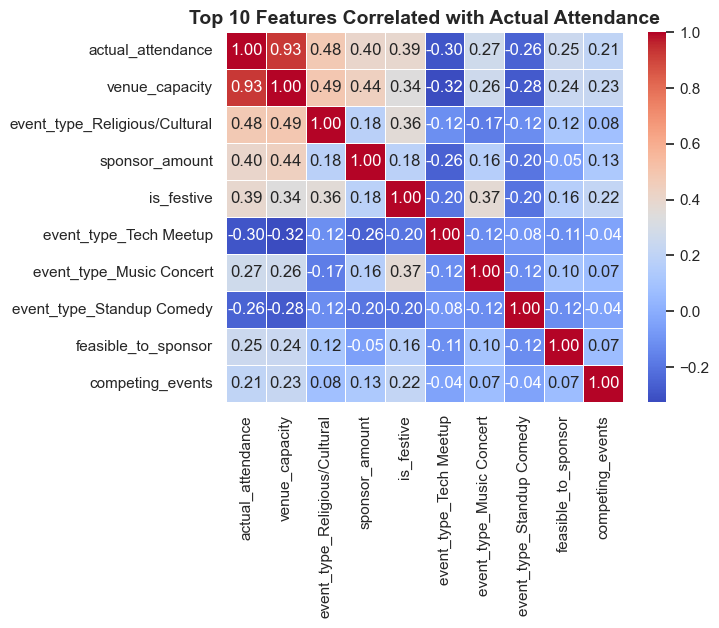

In [48]:
top_corr_features = df.corr()['actual_attendance'].abs().sort_values(ascending=False).head(10).index
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Top 10 Features Correlated with Actual Attendance", fontsize=14, fontweight='bold')
plt.show()

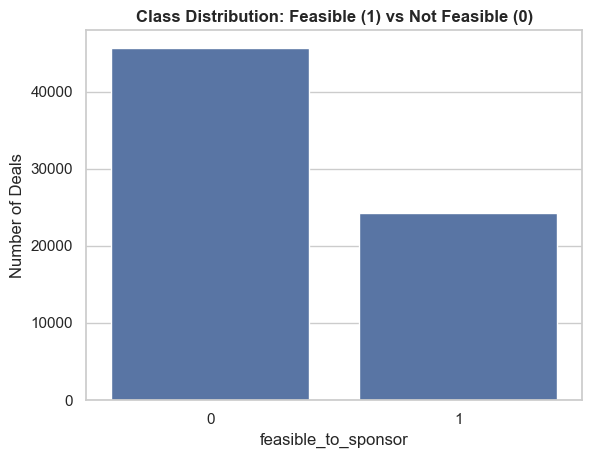

In [49]:
sns.countplot(data=df, x='feasible_to_sponsor')
plt.title("Class Distribution: Feasible (1) vs Not Feasible (0)", fontsize=12, fontweight='bold')
plt.ylabel("Number of Deals")
plt.show()

In [50]:
X_base = df.drop(columns=['actual_attendance', 'feasible_to_sponsor'])
y_attendance = df['actual_attendance']
y_feasible = df['feasible_to_sponsor']

In [51]:
X_train, X_test, y_train_att, y_test_att, y_train_feas, y_test_feas = train_test_split(
    X_base, y_attendance, y_feasible, test_size=0.2, random_state=42
)

In [52]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
regressors = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
}

In [54]:
results_att = []
for name, model in regressors.items():
    model.fit(X_train_scaled, y_train_att)
    preds = model.predict(X_test_scaled)
    r2 = r2_score(y_test_att, preds)
    mae = mean_absolute_error(y_test_att, preds)
    results_att.append({"Model": name, "R-Squared": r2, "MAE": mae})

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010587 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3214
[LightGBM] [Info] Number of data points in the train set: 56000, number of used features: 67
[LightGBM] [Info] Start training from score 14864.349893
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [55]:
results_df = pd.DataFrame(results_att).sort_values(by="R-Squared", ascending=False) 

In [56]:
results_df

,Model,R-Squared,MAE
2,Random Forest,0.974730,1376.316117
3,XGBoost,0.969195,1503.221183
1,Decision Tree,0.963250,1596.733951
4,LightGBM,0.963000,1638.711372
0,Linear Regression,0.911136,2679.821216


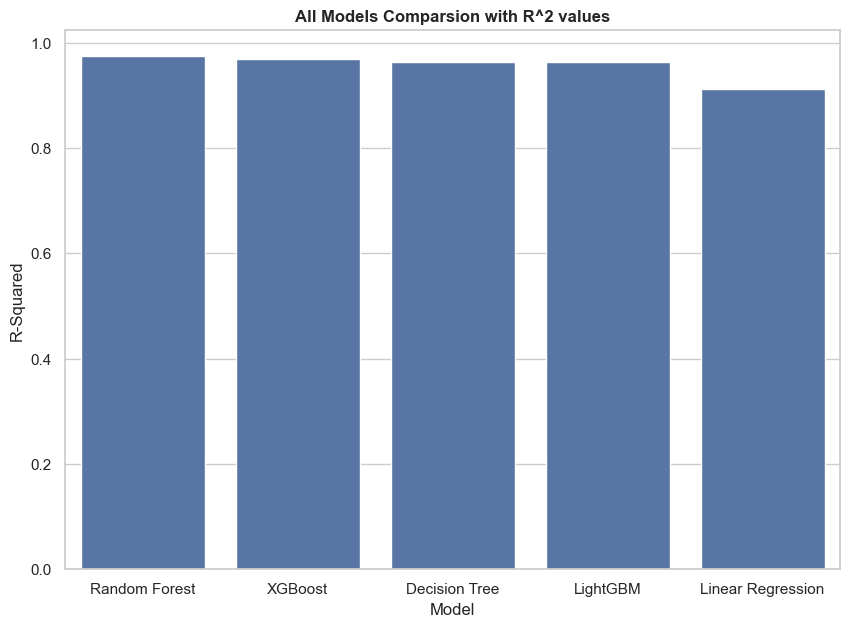

In [57]:
plt.figure(figsize=(10, 7))
sns.barplot(data=results_df, x=results_df['Model'], y=results_df['R-Squared'])
plt.title("All Models Comparsion with R^2 values", fontweight='bold')
plt.show()

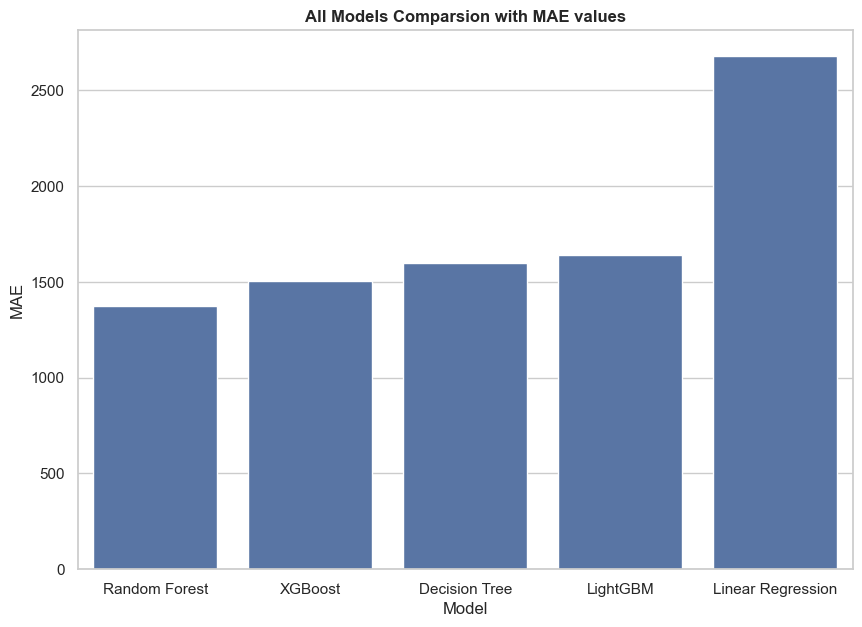

In [58]:
plt.figure(figsize=(10, 7))
sns.barplot(data=results_df, x=results_df['Model'], y=results_df['MAE'])
plt.title("All Models Comparsion with MAE values", fontweight='bold')
plt.show()

In [59]:
best_reg_name = results_df.iloc[0]['Model']
best_reg_model = regressors[best_reg_name]
print(f"\n Best Regressor: {best_reg_name}")


 Best Regressor: Random Forest


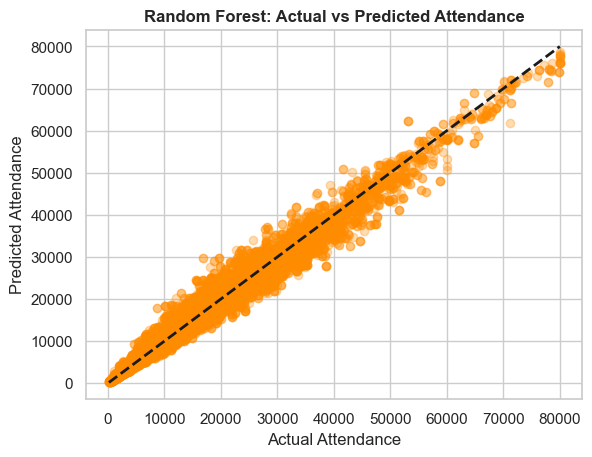

In [60]:
best_preds = best_reg_model.predict(X_test_scaled)
plt.scatter(y_test_att, best_preds, alpha=0.3, color='darkorange')
plt.plot([y_test_att.min(), y_test_att.max()], [y_test_att.min(), y_test_att.max()], 'k--', lw=2)
plt.xlabel("Actual Attendance")
plt.ylabel("Predicted Attendance")
plt.title(f"{best_reg_name}: Actual vs Predicted Attendance", fontweight='bold')
plt.show()

In [61]:
attendance_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
attendance_model.fit(X_train_scaled, y_train_att)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [62]:
train_predicted_attendance = cross_val_predict(attendance_model, X_train_scaled, y_train_att, cv=5, n_jobs=-1)
attendance_model.fit(X_train_scaled, y_train_att)
test_predicted_attendance = attendance_model.predict(X_test_scaled)

In [63]:
r2 = r2_score(y_test_att, test_predicted_attendance)
print(f"Attendance Model R-Squared: {r2:.4f}\n")

Attendance Model R-Squared: 0.9871



In [64]:
X_train_stage2 = np.column_stack((X_train_scaled, train_predicted_attendance))
X_test_stage2 = np.column_stack((X_test_scaled, test_predicted_attendance))

In [65]:
# class imbalance for feasibility
scale_weight = (y_train_feas == 0).sum() / (y_train_feas == 1).sum()
scale_weight

np.float64(1.8842192006592502)

In [66]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, scale_pos_weight=10, random_state=42, n_jobs=-1)
}

In [67]:
results_cls = []
for name, model in classifiers.items():
    model.fit(X_train_stage2, y_train_feas)
    preds = model.predict(X_test_stage2)
    acc = accuracy_score(y_test_feas, preds)
    results_cls.append({"Model": name, "Accuracy": acc})

c:\Users\risha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [68]:
results_cls_df = pd.DataFrame(results_cls).sort_values(by="Accuracy", ascending=False)
results_cls_df.head()

,Model,Accuracy
1,Random Forest,0.799357
0,Logistic Regression,0.771857
2,XGBoost,0.630929


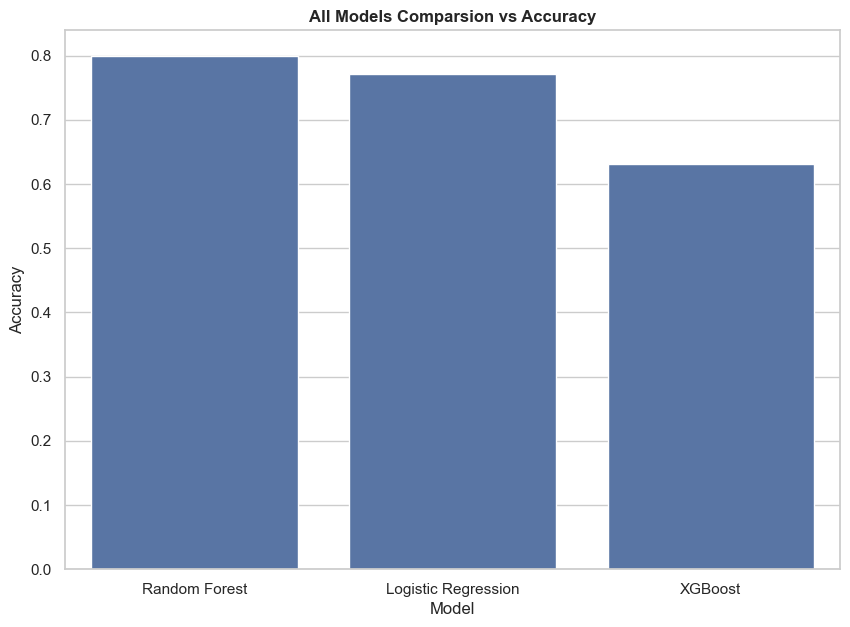

In [69]:
plt.figure(figsize=(10, 7))
sns.barplot(data=results_cls_df, x=results_cls_df['Model'], y=results_cls_df['Accuracy'])
plt.title("All Models Comparsion vs Accuracy", fontweight='bold')
plt.show()

In [70]:
best_cls_name = results_cls_df.iloc[0]['Model']
best_clf = classifiers[best_cls_name]
print(f"\nBest Classifier: {best_cls_name}")


Best Classifier: Random Forest


In [71]:
sponsor_model = XGBClassifier(scale_pos_weight=scale_weight, random_state=42, n_jobs=-1)
sponsor_model.fit(X_train_stage2, y_train_feas)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [72]:
final_predictions = sponsor_model.predict(X_test_stage2)

In [73]:
print(classification_report(y_test_feas, final_predictions))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85      9102
           1       0.73      0.71      0.72      4898

    accuracy                           0.81     14000
   macro avg       0.79      0.79      0.79     14000
weighted avg       0.81      0.81      0.81     14000



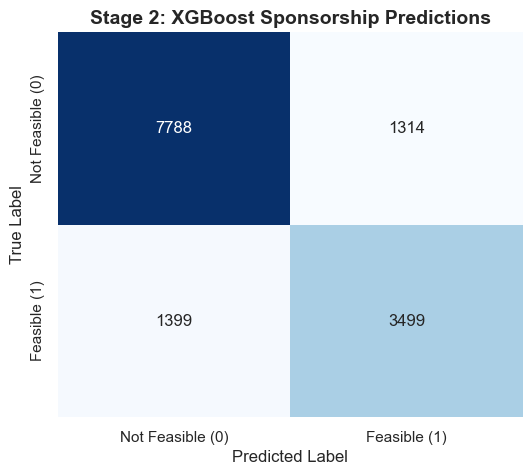

In [74]:
cm = confusion_matrix(y_test_feas, final_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Not Feasible (0)', 'Feasible (1)'],
            yticklabels=['Not Feasible (0)', 'Feasible (1)'])
plt.title('Stage 2: XGBoost Sponsorship Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [75]:
scaler_full = StandardScaler()
X_base_scaled_full = scaler_full.fit_transform(X_base)

In [76]:
final_attendance_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)

In [77]:
full_predicted_attendance = cross_val_predict(final_attendance_model, X_base_scaled_full, y_attendance, cv=5, n_jobs=-1)

In [78]:
final_attendance_model.fit(X_base_scaled_full, y_attendance)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [79]:
X_full_stage2 = np.column_stack((X_base_scaled_full, full_predicted_attendance))

In [80]:
scale_weight_full = (y_feasible == 0).sum() / (y_feasible == 1).sum()

final_sponsor_model = XGBClassifier(scale_pos_weight=scale_weight_full, random_state=42, n_jobs=-1)

In [81]:
final_sponsor_model.fit(X_full_stage2, y_feasible)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [82]:
import joblib
joblib.dump(final_attendance_model, 'stage1_attendance_xgboost.pkl')
joblib.dump(final_sponsor_model, 'stage2_sponsor_xgboost.pkl')
joblib.dump(scaler_full, 'feature_scaler.pkl')

['feature_scaler.pkl']